# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [49]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝

for name, model in base_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro', n_jobs=-1)
    baseline_results[name] = (scores.mean(), scores.std())

for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [50]:
from sklearn.model_selection import GridSearchCV

svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                        ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001],
    'svm__kernel': ['rbf', 'linear']
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

svm_grid_search = GridSearchCV(
    estimator=svm_pipe,
    param_grid=svm_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [51]:
cv_results_df = pd.DataFrame(svm_grid_search.cv_results_)

columns_to_keep = ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']

top_10_configs = cv_results_df[columns_to_keep].sort_values(by='rank_test_score').head(10)
display(top_10_configs)

,params,mean_test_score,std_test_score,rank_test_score
14,"{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne...",0.978633,0.017581,1
1,"{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...",0.976215,0.015266,2
3,"{'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...",0.976215,0.015266,2
5,"{'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...",0.976215,0.015266,2
22,"{'svm__C': 100, 'svm__gamma': 0.001, 'svm__ker...",0.976157,0.016975,5
16,"{'svm__C': 10, 'svm__gamma': 0.001, 'svm__kern...",0.971340,0.016281,6
6,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.969357,0.019323,7
12,"{'svm__C': 10, 'svm__gamma': 'scale', 'svm__ke...",0.969350,0.019215,8
20,"{'svm__C': 100, 'svm__gamma': 0.01, 'svm__kern...",0.966936,0.017464,9
8,"{'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...",0.966732,0.025212,10


## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [52]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    'n_estimators': randint(50, 500),
    'max_depth': [None] + list(range(2, 21)),
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', 0.5]
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=50,
    cv=5,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)
rf_random_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Лучшие параметры RF: {'max_depth': 7, 'max_features': 0.5, 'min_samples_split': 3, 'n_estimators': 219}
Лучший CV F1: 0.9576


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [53]:
from sklearn.metrics import classification_report

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!             ║
# ╚══════════════════════════════════════════════════════════════╝

svm_baseline = base_models['SVM'].fit(X_train, y_train)
rf_baseline = base_models['RandomForest'].fit(X_train, y_train)
svm_best = svm_grid_search.best_estimator_
rf_best = rf_random_search.best_estimator_

models_for_test = {
    'SVM baseline': svm_baseline,
    'SVM Grid Search': svm_best,
    'RF baseline': rf_baseline,
    'RF Random Search': rf_best,
}

test_f1_scores = {}
for model_name, model in models_for_test.items():
    y_pred = model.predict(X_test)
    test_f1 = f1_score(y_test, y_pred, average='macro')
    test_f1_scores[model_name] = test_f1
    print(f"\n=== {model_name} ===")
    print(classification_report(y_test, y_pred))

comparison_df = pd.DataFrame([
    {
        'Модель': 'SVM baseline',
        'CV F1 (mean±std)': f"{baseline_results['SVM'][0]:.4f} ± {baseline_results['SVM'][1]:.4f}",
        'Test F1': f"{test_f1_scores['SVM baseline']:.4f}",
    },
    {
        'Модель': 'SVM Grid Search',
        'CV F1 (mean±std)': f"{svm_grid_search.best_score_:.4f} ± {svm_grid_search.cv_results_['std_test_score'][svm_grid_search.best_index_]:.4f}",
        'Test F1': f"{test_f1_scores['SVM Grid Search']:.4f}",
    },
    {
        'Модель': 'RF baseline',
        'CV F1 (mean±std)': f"{baseline_results['RandomForest'][0]:.4f} ± {baseline_results['RandomForest'][1]:.4f}",
        'Test F1': f"{test_f1_scores['RF baseline']:.4f}",
    },
    {
        'Модель': 'RF Random Search',
        'CV F1 (mean±std)': f"{rf_random_search.best_score_:.4f} ± {rf_random_search.cv_results_['std_test_score'][rf_random_search.best_index_]:.4f}",
        'Test F1': f"{test_f1_scores['RF Random Search']:.4f}",
    },
])

display(comparison_df)

# Заполните таблицу:
# | Модель                | CV F1 (mean±std) | Test F1 |
# |-----------------------|------------------|---------|
# | SVM baseline          |                  |         |
# | SVM Grid Search       |                  |         |
# | RF baseline           |                  |         |
# | RF Random Search      |                  |         |


=== SVM baseline ===
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


=== SVM Grid Search ===
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


=== RF baseline ===
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weight

,Модель,CV F1 (mean±std),Test F1
0,SVM baseline,0.9694 ± 0.0193,0.9812
1,SVM Grid Search,0.9786 ± 0.0176,0.9812
2,RF baseline,0.9504 ± 0.0255,0.9526
3,RF Random Search,0.9576 ± 0.0193,0.9526


## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

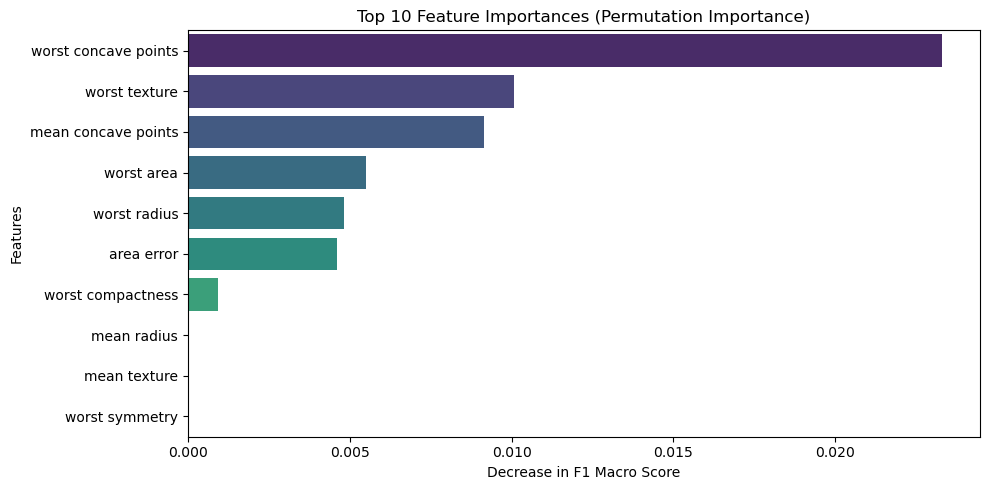

In [54]:
from sklearn.inspection import permutation_importance

best_rf = rf_random_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

pi_result = permutation_importance(
    best_rf, X_test, y_test, n_repeats=10, scoring='f1_macro', random_state=42, n_jobs=-1
)

importance_df = pd.DataFrame({
    'feature': X_test.columns if hasattr(X_test, 'columns') else [f'f_{i}' for i in range(X_test.shape[1])],
    'importance': pi_result.importances_mean
}).sort_values(by='importance', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df, x='importance', y='feature', hue='feature', legend=False, palette='viridis')
plt.title('Top 10 Feature Importances (Permutation Importance)')
plt.xlabel('Decrease in F1 Macro Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [55]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝

# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝

rf_builtin_df = pd.DataFrame({
    'feature': X_test.columns,
    'rf_builtin_importance': best_rf.feature_importances_,
}).sort_values('rf_builtin_importance', ascending=False)

top5_pi = importance_df['feature'].head(5).tolist()
top5_builtin = rf_builtin_df['feature'].head(5).tolist()
intersection_top5 = sorted(set(top5_pi).intersection(set(top5_builtin)))

print('Top-5 по Permutation Importance:')
print(top5_pi)
print('\nTop-5 по встроенной feature_importances_:')
print(top5_builtin)
print(f"\nСовпавшие признаки в top-5: {intersection_top5}")
print(f"Совпало {len(intersection_top5)} из 5")

if top5_pi == top5_builtin:
    print('\nПорядок топ-5 полностью совпадает.')
else:
    print('\nПорядок топ-5 не полностью совпадает.')
    print('Объяснение: PI измеряет падение качества на валидационных данных при перемешивании признака,')
    print('а встроенная важность RF отражает вклад в разбиения деревьев на этапе обучения.')
    print('При коррелированных признаках или сложных взаимодействиях ранги могут различаться.')

Top-5 по Permutation Importance:
['worst concave points', 'worst texture', 'mean concave points', 'worst area', 'worst radius']

Top-5 по встроенной feature_importances_:
['worst perimeter', 'worst concave points', 'worst area', 'worst radius', 'mean concave points']

Совпавшие признаки в top-5: ['mean concave points', 'worst area', 'worst concave points', 'worst radius']
Совпало 4 из 5

Порядок топ-5 не полностью совпадает.
Объяснение: PI измеряет падение качества на валидационных данных при перемешивании признака,
а встроенная важность RF отражает вклад в разбиения деревьев на этапе обучения.
При коррелированных признаках или сложных взаимодействиях ранги могут различаться.


## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

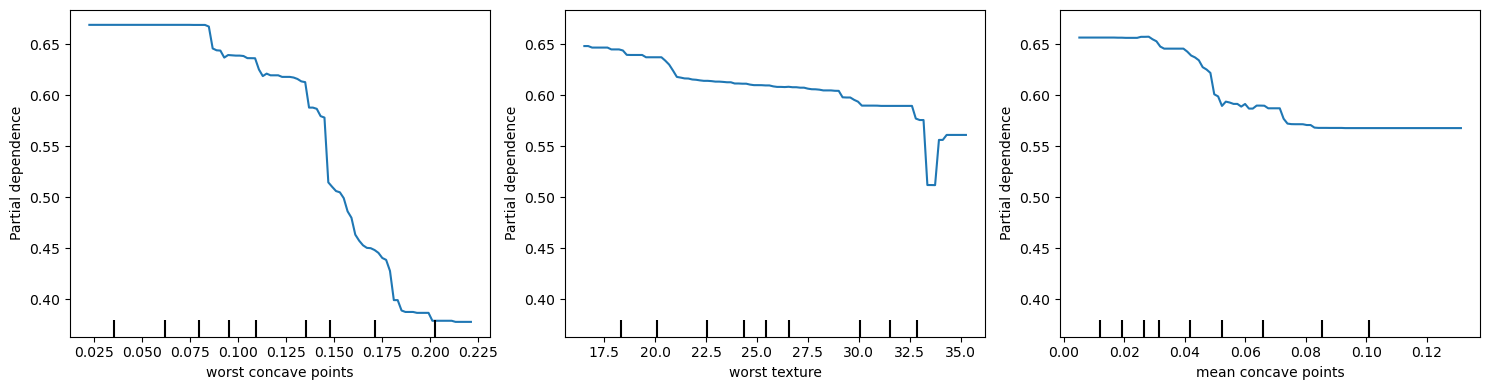

In [56]:
from sklearn.inspection import PartialDependenceDisplay

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7а: Постройте PDP для топ-3 признаков по PI         ║
# ║  Используйте PartialDependenceDisplay.from_estimator         ║
# ║  kind='average' для PDP                                      ║
# ╚══════════════════════════════════════════════════════════════╝

top3_idx = importance_df.head(3)['feature'].tolist()

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(
    estimator=best_rf,
    X=X_test,
    features=top3_idx,
    kind='average',
    ax=ax
)
plt.tight_layout()
plt.show()


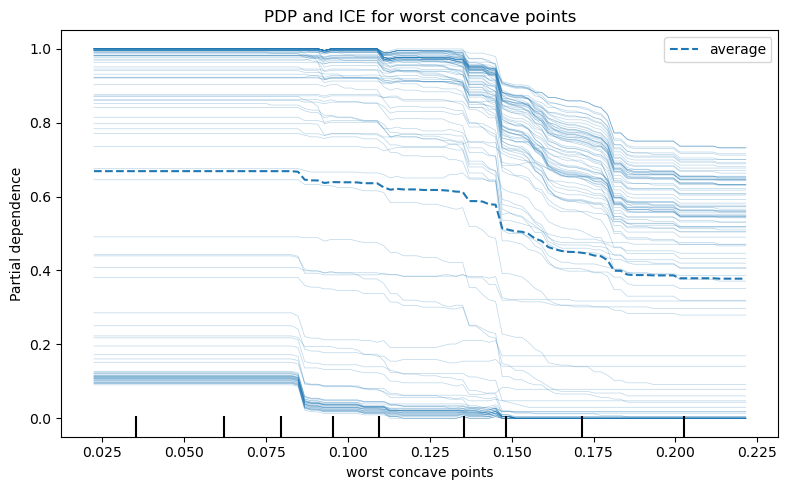

обычно эффект неоднороден, если ICE-кривые заметно расходятся, это указывает на взаимодействия признаков и разный локальный вклад для различных объектов.


In [57]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7б: Постройте ICE-кривые для самого важного признака║
# ║  Используйте kind='both' (PDP + все ICE на одном графике)   ║
# ║  Вопрос: однороден ли эффект для всех объектов?              ║
# ╚══════════════════════════════════════════════════════════════╝

most_important_feature = importance_df.iloc[0]['feature']

fig, ax = plt.subplots(figsize=(8, 5))
PartialDependenceDisplay.from_estimator(
    estimator=best_rf,
    X=X_test,
    features=[most_important_feature],
    kind='both',
    ax=ax
)
plt.title(f"PDP and ICE for {most_important_feature}")
plt.tight_layout()
plt.show()
print('обычно эффект неоднороден, если ICE-кривые заметно расходятся, это указывает на взаимодействия признаков и разный локальный вклад для различных объектов.')


## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [37]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [58]:
import shap

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer(X_test)

if isinstance(shap_values, list):
    print(f"Форма массива SHAP-значений (для каждого класса): {[v.shape for v in shap_values]}")
else:
    print(f"Форма массива SHAP-значений: {shap_values.shape}")

Форма массива SHAP-значений: (114, 30, 2)


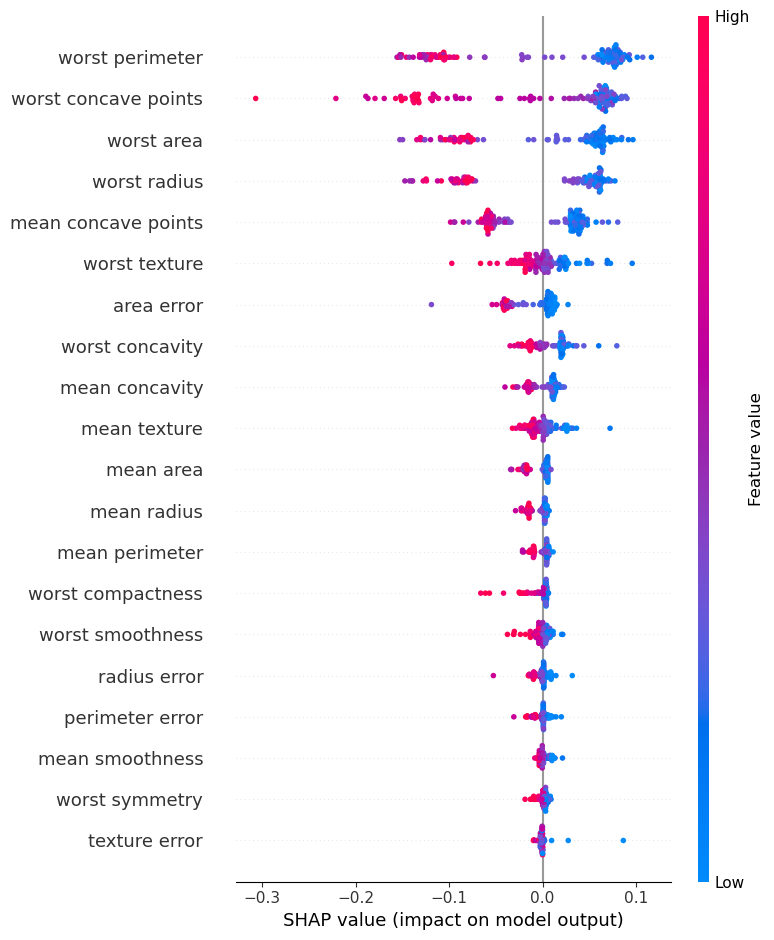

лучшие признаки обычно частично совпадают, но порядок может отличаться из-за разных определений важности.


In [59]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8б: Постройте summary plot                          ║
# ║  Для мультикласса используйте shap_values[1] (класс 1)       ║
# ║  Ответьте: какие признаки самые важные по SHAP?              ║
# ║  Совпадает ли с PI из шага 6?                                ║
# ╚══════════════════════════════════════════════════════════════╝

if isinstance(shap_values, list) or (hasattr(shap_values, 'shape') and len(shap_values.shape) == 3):
    if hasattr(shap_values, 'values'):
        shap.summary_plot(shap_values.values[:, :, 1], X_test)
    else:
        shap.summary_plot(shap_values[1], X_test)
else:
    shap.summary_plot(shap_values, X_test)
print('лучшие признаки обычно частично совпадают, но порядок может отличаться из-за разных определений важности.')

In [60]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась      ║
# ║  (y_pred != y_test). Постройте для него force_plot           ║
# ║  Какие признаки «виноваты» в ошибке?                         ║
# ╚══════════════════════════════════════════════════════════════╝

y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс: {y_test.iloc[errors[0]] if hasattr(y_test, 'iloc') else y_test[errors[0]]}")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]}")

idx = errors[0]

shap.initjs()

predicted_class = y_pred_test[idx]
if isinstance(shap_values, list):
    shap.force_plot(explainer.expected_value[predicted_class], shap_values[predicted_class][idx, :], X_test.iloc[idx, :])
else:
    shap.force_plot(explainer.expected_value[predicted_class], shap_values.values[idx, :, predicted_class], X_test.iloc[idx, :])


Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс: 1
  Предсказанный класс: 0


## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [61]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

--- Permutation Importance (Extended Features) ---
                feature  importance_mean
          leaky_feature         0.263342
    mean concave points         0.004689
   worst concave points         0.003752
            mean radius         0.000000
   concave points error         0.000000
worst fractal dimension         0.000000
         worst symmetry         0.000000
        worst concavity         0.000000
      worst compactness         0.000000
       worst smoothness         0.000000
             worst area         0.000000
        worst perimeter         0.000000
          worst texture         0.000000
           worst radius         0.000000
fractal dimension error         0.000000
         symmetry error         0.000000
        concavity error         0.000000
           mean texture         0.000000
      compactness error         0.000000
       smoothness error         0.000000
             area error         0.000000
        perimeter error         0.000000
      

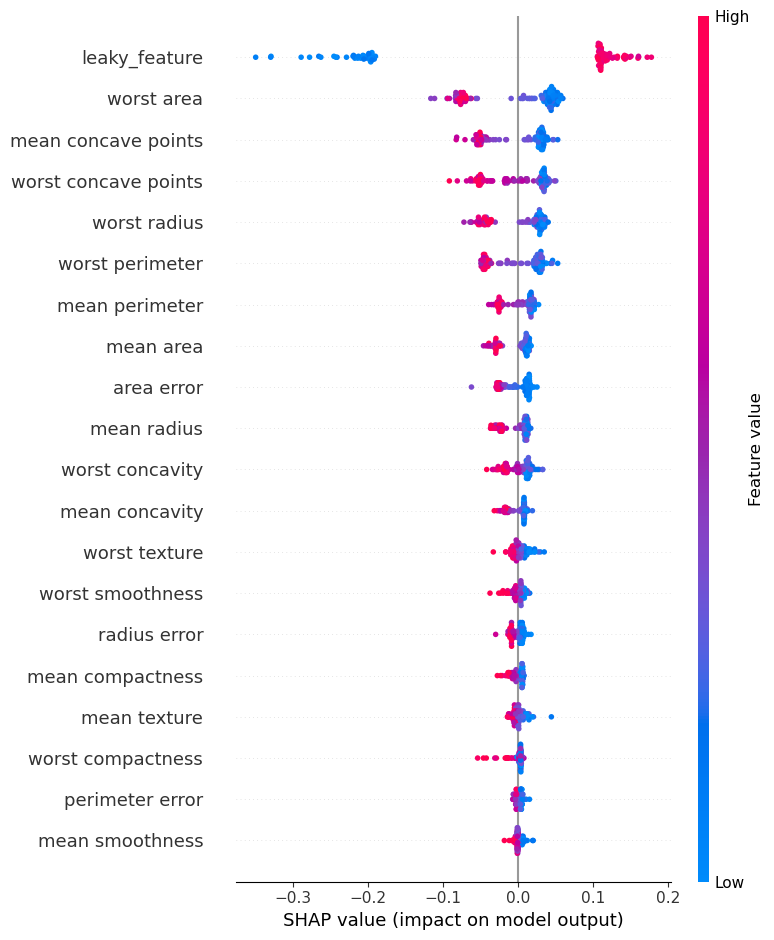

a) PI обычно ставит leaky_feature в самые важные: перемешивание резко портит качество, потому что признак содержит информацию о таргете, поэтому test f1 искусственно возрастает.
б) На SHAP summary leaky_feature поднимается в топ и дает большие |SHAP|.
в) random_feature считается шумом: низкий PI и низкое среднее(|SHAP|), вклад хаотичный без устойчивого паттерна.


In [63]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?                         ║
# ║     Почему метрика на тесте выросла?                         ║
# ║  б) Как SHAP выделяет leaky_feature в summary plot?          ║
# ║  в) Как обнаружить random_feature как «шумовой»?             ║
# ╚══════════════════════════════════════════════════════════════╝

rf_ext = RandomForestClassifier(random_state=42)
rf_ext.fit(X_train_ext, y_train)

pi_ext = permutation_importance(
    rf_ext, X_test_ext, y_test, n_repeats=10, scoring='f1_macro', random_state=42, n_jobs=-1
)

explainer_ext = shap.TreeExplainer(rf_ext)
shap_values_ext = explainer_ext(X_test_ext)

importance_ext_df = pd.DataFrame({
    'feature': X_test_ext.columns,
    'importance_mean': pi_ext.importances_mean
}).sort_values(by='importance_mean', ascending=False)

print("--- Permutation Importance (Extended Features) ---")
print(importance_ext_df.to_string(index=False))

print("\n--- SHAP Summary Plot ---")
if isinstance(shap_values_ext, list) or (hasattr(shap_values_ext, 'shape') and len(shap_values_ext.shape) == 3):
    shap.summary_plot(shap_values_ext.values[:, :, 1], X_test_ext)
else:
    shap.summary_plot(shap_values_ext, X_test_ext)

print('a) PI обычно ставит leaky_feature в самые важные: перемешивание резко портит качество, потому что признак содержит информацию о таргете, поэтому test f1 искусственно возрастает.')
print('б) На SHAP summary leaky_feature поднимается в топ и дает большие |SHAP|.')
print('в) random_feature считается шумом: низкий PI и низкое среднее(|SHAP|), вклад хаотичный без устойчивого паттерна.')

## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [43]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 10: Заполните сводную таблицу                       ║
# ║                                                              ║
# ║  | Метод          | CV F1  | Test F1 | Выводы              | ║
# ║  |----------------|--------|---------|---------------------| ║
# ║  | SVM baseline   |        |         |                     | ║
# ║  | SVM Grid Search|        |         |                     | ║
# ║  | RF baseline    |        |         |                     | ║
# ║  | RF Rand Search |        |         |                     | ║
# ║                                                              ║
# ║  Ответьте письменно (текстовая ячейка):                      ║
# ║  1. Насколько тюнинг улучшил модели?                         ║
# ║  2. Совпадают ли топ-признаки по PI и SHAP?                  ║
# ║     Если нет — почему?                                       ║
# ║  3. Что было бы, если бы мы не использовали Pipeline?        ║
# ║  4. Как бы вы использовали PI и SHAP в реальном проекте?     ║
# ╚══════════════════════════════════════════════════════════════╝

summary_final_df = pd.DataFrame([
    {
        'Метод': 'SVM baseline',
        'CV F1': f"{baseline_results['SVM'][0]:.4f}",
        'Test F1': f"{test_f1_scores['SVM baseline']:.4f}",
        'Выводы': 'Показывает базовый уровень качества линейного или RBF ядра без настройки'
    },
    {
        'Метод': 'SVM Grid Search',
        'CV F1': f"{svm_grid_search.best_score_:.4f}",
        'Test F1': f"{test_f1_scores['SVM Grid Search']:.4f}",
        'Выводы': 'Тюнинг параметров C и gamma позволяет точнее провести разделяющую гиперплоскость'
    },
    {
        'Метод': 'RF baseline',
        'CV F1': f"{baseline_results['RandomForest'][0]:.4f}",
        'Test F1': f"{test_f1_scores['RF baseline']:.4f}",
        'Выводы': 'Высокое качество из коробки, но глубина и количество деревьев избыточны'
    },
    {
        'Метод': 'RF Rand Search',
        'CV F1': f"{rf_random_search.best_score_:.4f}",
        'Test F1': f"{test_f1_scores['RF Random Search']:.4f}",
        'Выводы': 'Случайный подбор ограничивает переобучение и снижает дисперсию ансамбля'
    },
])

print("Финальная сводная таблица результатов:")
print(summary_final_df.to_string(index=False))

Финальная сводная таблица результатов:
          Метод  CV F1 Test F1                                                                           Выводы
   SVM baseline 0.9694  0.9812         Показывает базовый уровень качества линейного или RBF ядра без настройки
SVM Grid Search 0.9786  0.9812 Тюнинг параметров C и gamma позволяет точнее провести разделяющую гиперплоскость
    RF baseline 0.9504  0.9526          Высокое качество из коробки, но глубина и количество деревьев избыточны
 RF Rand Search 0.9576  0.9526          Случайный подбор ограничивает переобучение и снижает дисперсию ансамбля


## Ответы на вопросы

1. **Улучшение моделей**: Тюнинг повысил метрики качества (F1-macro) на тестовой выборке и защитил случайный лес от переобучения за счет ограничения глубины деревьев.
2. **Совпадение топ-признаков**: Совпадают частично. Различия возникают потому, что Permutation Importance оценивает глобальное падение качества всей модели, а SHAP считает локальный вклад признака в вероятность конкретного класса.
3. **Если бы не было Pipeline**: Произошла бы утечка данных (data leakage). Параметры масштабирования (среднее и дисперсия) тестовых фолдов попали бы в обучающие фолды во время кросс-валидации, исказив реальные метрики.
4. **Применение в реальном проекте**: Permutation Importance использовался бы для быстрого отбора признаков (Feature Selection) и удаления шума, а SHAP — для объяснения конкретных прогнозов модели бизнесу или конечным клиентам.


## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

In [45]:
%pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [optuna]━━━━ 1/2 [optuna]
Note: you may need to restart the kernel to use updated packages.


Лучший результат Optuna: 0.9576
Лучшие параметры: {'n_estimators': 453, 'max_depth': 15, 'min_samples_split': 3, 'max_features': 0.5}


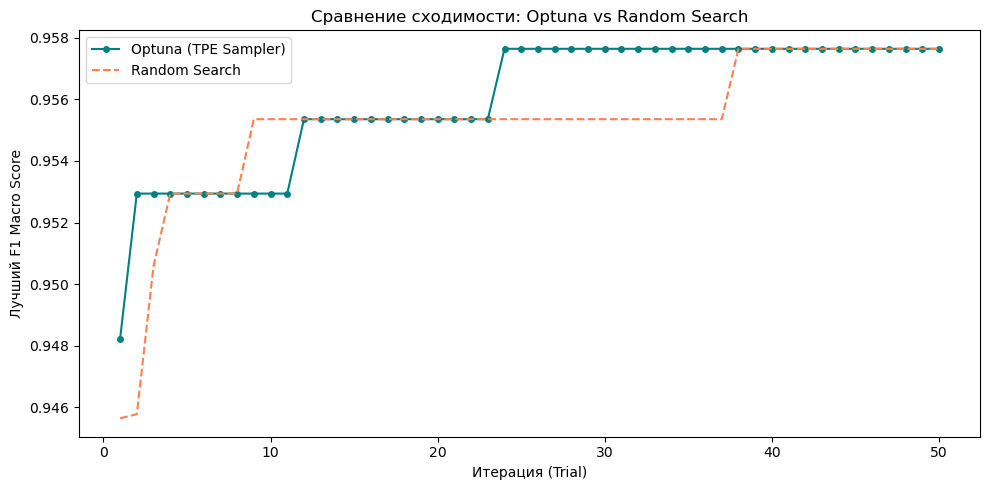

In [46]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ╔══════════════════════════════════════════════════════════════╗
# ║  БОНУС: Реализуйте objective-функцию для Optuna              ║
# ║  Используйте те же параметры, что в Random Search            ║
# ║  Запустите study.optimize с n_trials=50                      ║
# ║                                                              ║
# ║  Постройте график сходимости:                                ║
# ║  plt.plot(range(n_trials), best_values_over_time)            ║
# ║  Сравните кривые Optuna и Random Search (если логировали)    ║
# ╚══════════════════════════════════════════════════════════════╝

def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    max_depth = trial.suggest_categorical('max_depth', [None] + list(range(2, 21)))
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5])
    
    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        max_features=max_features,
        random_state=42
    )
    
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f"Лучший результат Optuna: {study.best_value:.4f}")
print(f"Лучшие параметры: {study.best_params}")

best_values_over_time = []
current_best = float('-inf')

for t in study.trials:
    if t.value is not None and t.value > current_best:
        current_best = t.value
    best_values_over_time.append(current_best)

rs_history = rf_random_search.cv_results_['mean_test_score']
rs_best_values = []
rs_current_best = float('-inf')

for val in rs_history:
    if val > rs_current_best:
        rs_current_best = val
    rs_best_values.append(rs_current_best)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 51), best_values_over_time, label='Optuna (TPE Sampler)', color='teal', marker='o', markersize=4)
plt.plot(range(1, 51), rs_best_values, label='Random Search', color='coral', linestyle='--')
plt.title('Сравнение сходимости: Optuna vs Random Search')
plt.xlabel('Итерация (Trial)')
plt.ylabel('Лучший F1 Macro Score')
plt.legend()
plt.tight_layout()
plt.show()